<a href="https://colab.research.google.com/github/braim/nids-tta/blob/main/colab/8-tt/NIDS_8_0_0_CTTA_TT_CICIDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NIDS — AE+Classifier with Few-Shot Layer-Selective CTTA

## Design

**Pre-training:** supervised CE + reconstruction MSE on fully labelled source.

**CTTA strategy — Layer-Selective Updates:**
Three parameter groups are updated during CTTA:
1. **Norm layers** (LayerNorm, GroupNorm) — adapt feature normalisation statistics
2. **Classifier head** — directly moves the decision boundary toward target patterns
3. **Last encoder layer** — adapts the final feature representation

The early encoder layers (source feature extractors) remain frozen.
This gives the CE loss a direct path to update the decision boundary
while protecting source representations from catastrophic forgetting.

**Three loss signals per batch (all requiring only 1% labelled pool):**
1. Supervised CE on labelled pool — moves decision boundary to target domain
2. Entropy minimisation on stream — increases prediction confidence
3. Reconstruction on pool — keeps representations grounded

## Architectures
| `ARCH` | Description |
|---|---|
| `'kan'` | KAN encoder/decoder + linear classifier |
| `'cnn'` | CNN encoder/decoder + linear classifier |
| `'transformer'` | Transformer encoder/decoder + linear classifier |

In [15]:
!pip install -q git+https://github.com/Blealtan/efficient-kan.git
!pip install -q polars kagglehub

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. Imports & Configuration

In [16]:
# Install necessary libraries and import
import os, gc, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import polars as pl
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score
from dataclasses import dataclass
import torch
import numpy as np
import random
from efficient_kan import KAN


In [17]:
@dataclass
class Hyperparameters:
    # ── Reproducibility ───────────────────────────────────────────────────────────
    seed: int = 42
    # ── Architecture ──────────────────────────────────────────────────────────────
    arch: str = 'kan'    # 'kan' | 'cnn' | 'transformer'
    # ── Data ──────────────────────────────────────────────────────────────────────
    sample_n: int = 100_000
    batch_size: int = 128
    tta_batch_size: int = 512
    # ── Model ─────────────────────────────────────────────────────────────────────
    latent_dim: int = 32
    n_heads: int = 4
    n_layers: int = 2
    ff_dim: int = 128
    dropout: float = 0.1
    # ── Pre-training ──────────────────────────────────────────────────────────────
    pretrain_epochs: int = 20
    pretrain_lr: float = 1e-3
    weight_decay: float = 1e-4
    recon_w: float = 0.5         # Reconstruction weight during pre-training
    # ── CTTA ──────────────────────────────────────────────────────────────────────
    few_shot_ratio: float = 0.01 # Fraction of target data used as labelled pool
    few_shot_w: float = 1.0      # Supervised CE weight during CTTA
    tta_lr: float = 1e-3         # Learning rate for layer-selective updates
    tta_steps: int = 1           # Gradient steps per batch
    entropy_w: float = 1.0       # Entropy minimisation weight
    recon_w_tta: float = 0.5     # Reconstruction weight during CTTA

config = Hyperparameters()
print(f"Hyperparameters: {config}")

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(config.seed)
torch.cuda.manual_seed_all(config.seed)
np.random.seed(config.seed)
random.seed(config.seed)
torch.backends.cudnn.deterministic = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'[System] Seed={config.seed} | Device={device} | Arch={config.arch}')

Hyperparameters: Hyperparameters(seed=42, arch='kan', sample_n=100000, batch_size=128, tta_batch_size=512, latent_dim=32, n_heads=4, n_layers=2, ff_dim=128, dropout=0.1, pretrain_epochs=20, pretrain_lr=0.001, weight_decay=0.0001, recon_w=0.5, few_shot_ratio=0.01, few_shot_w=1.0, tta_lr=0.001, tta_steps=1, entropy_w=1.0, recon_w_tta=0.5)
[System] Seed=42 | Device=cpu | Arch=kan


## 2. Data Loading & Preprocessing

In [18]:
def engineer_features(df: pl.DataFrame) -> pl.DataFrame:
    """Derive flow-level features and drop identifier/label columns."""
    if 'FLOW_END_MILLISECONDS' in df.columns and 'FLOW_START_MILLISECONDS' in df.columns:
        df = df.with_columns(
            (pl.col('FLOW_END_MILLISECONDS') - pl.col('FLOW_START_MILLISECONDS')).alias('FLOW_DURATION')
        )
    else:
        df = df.with_columns(pl.lit(0).alias('FLOW_DURATION'))
    if 'IN_BYTES' in df.columns and 'IN_PKTS' in df.columns:
        df = df.with_columns(
            (pl.col('IN_BYTES') / (pl.col('IN_PKTS') + 1e-5)).alias('BYTES_PER_PKT')
        )
    log_cols = ['IN_BYTES', 'IN_PKTS', 'FLOW_DURATION', 'SRC_TO_DST_IAT_MAX', 'DST_TO_SRC_IAT_MAX']
    existing = [c for c in log_cols if c in df.columns]
    if existing:
        df = df.with_columns([pl.col(c).log1p() for c in existing])
    drop_cols = [
        'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS',
        'IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'L4_SRC_PORT', 'L4_DST_PORT',
        'Label', 'Attack', 'label', 'attack', 'Date',
    ]
    df = df.drop([c for c in drop_cols if c in df.columns])
    return df


def load_dataset(dataset_name: str, sample_n: int = None):
    """Download dataset and return (X, y). Uses random sampling."""
    print(f'[Data] Loading {dataset_name} ...')
    path = kagglehub.dataset_download(dataset_name)
    csv_files = [
        os.path.join(root, f)
        for root, _, files in os.walk(path)
        for f in files if f.endswith('.csv')
    ]
    df = pl.scan_csv(csv_files[0]).collect(engine='streaming')
    if sample_n and sample_n < df.height:
        df = df.sample(n=sample_n, seed=config.seed)
    label_col = next((c for c in df.columns if c.lower() == 'label'), None)
    y = df[label_col].to_numpy().astype(np.int64) if label_col else np.zeros(df.height, dtype=np.int64)
    df = engineer_features(df)
    X  = df.to_numpy().astype(np.float32)
    X  = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    print(f'   -> Shape: {X.shape} | Attack rate: {np.mean(y):.2%}')
    return X, y


def make_source_loaders(X, y):
    """
    Stratified 80/20 split. Scaler fitted on full training split.
    Training loader contains all labelled samples (benign + attack).
    """
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=config.seed, stratify=y
    )
    scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_tr)
    X_tr   = np.clip(scaler.transform(X_tr).astype(np.float32), -1, 1)
    X_te   = np.clip(scaler.transform(X_te).astype(np.float32), -1, 1)
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
    loader_tr = DataLoader(train_ds, batch_size=config.batch_size,     shuffle=True)
    loader_te = DataLoader(test_ds,  batch_size=config.tta_batch_size, shuffle=False)
    return loader_tr, loader_te, scaler


def make_target_loaders(X, y):
    """
    Fit a fresh MinMaxScaler on the full target dataset (no label leakage).

    Stratified split into:
      pool_loader   : config.few_shot_ratio of data, labelled (both classes preserved)
      stream_loader : remaining data, labels kept for evaluation only

    The pool is used for supervised CE anchoring during CTTA.
    Real-world justification: the pool represents a brief initial analyst
    review period at deployment — a realistic assumption.
    """
    scaler   = MinMaxScaler(feature_range=(-1, 1)).fit(X)
    X_scaled = np.clip(scaler.transform(X).astype(np.float32), -1, 1)

    # Stratified split — both classes represented in pool
    X_pool, X_stream, y_pool, y_stream = train_test_split(
        X_scaled, y,
        test_size=(1 - config.few_shot_ratio),
        random_state=config.seed,
        stratify=y,
    )

    pool_ds   = TensorDataset(torch.from_numpy(X_pool),   torch.from_numpy(y_pool))
    stream_ds = TensorDataset(torch.from_numpy(X_stream), torch.from_numpy(y_stream))

    pool_loader   = DataLoader(pool_ds,   batch_size=config.batch_size,     shuffle=True)
    stream_loader = DataLoader(stream_ds, batch_size=config.tta_batch_size, shuffle=True)

    print(f'   -> Pool: {len(y_pool)} samples '
          f'(attack rate: {np.mean(y_pool):.2%}) | '
          f'Stream: {len(y_stream)} '
          f'(attack rate: {np.mean(y_stream):.2%})')
    return pool_loader, stream_loader


## 3. Model Architectures

In [19]:
# ==========================================
# MODEL: KAN AE+Classifier with  Memory Module  (Gong et al. 2019)
# ==========================================
class KanAEClassifier(nn.Module):
    """
    Shared KAN encoder → classifier head + decoder head.
    Encoder:    input_dim -> 64 -> latent_dim  (KAN)
    Classifier: latent_dim -> 2               (Linear)
    Decoder:    latent_dim -> 64 -> input_dim  (KAN)
    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder    = KAN([input_dim, 64, latent_dim], grid_range=[-1, 1])
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder    = KAN([latent_dim, 64, input_dim], grid_range=[-1, 1])

    def forward(self, x):
        z = self.ln(self.encoder(x))
        return self.classifier(z), self.decoder(z), z


# ==========================================
# MODEL: CNN AE+Classifier
# ==========================================
class CnnAEClassifier(nn.Module):
    """
    Shared CNN encoder → classifier head + decoder head.
    Each feature becomes its own channel (seq len=1). Pointwise Conv1d.
    GroupNorm(1,C) robust to variable attack rates.
    Encoder:    input_dim -> 64 -> latent_dim  (Conv1d)
    Classifier: latent_dim -> 2               (Linear)
    Decoder:    latent_dim -> 64 -> input_dim  (ConvTranspose1d)
    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.Conv1d(64, latent_dim, kernel_size=1),
        )
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.ConvTranspose1d(64, input_dim, kernel_size=1),
        )

    def forward(self, x):
        z     = self.ln(self.encoder(x.unsqueeze(-1)).squeeze(-1))
        recon = self.decoder(z.unsqueeze(-1)).squeeze(-1)
        return self.classifier(z), recon, z


# ==========================================
# MODEL: Transformer AE+Classifier
# ==========================================
class TransformerAEClassifier(nn.Module):
    """
    Transformer encoder → classifier head + decoder head.

    Each input feature is projected to latent_dim, forming a sequence of
    input_dim tokens. Multi-head self-attention models pairwise feature
    interactions explicitly — more principled than CNN pointwise mixing
    for NetFlow features where interactions are semantically meaningful.

    Encoder:    (B, input_dim) → feature_embed → (B, input_dim, latent_dim)
                → N_LAYERS × TransformerEncoderLayer → mean pool → (B, latent_dim)
    Classifier: latent_dim → 2
    Decoder:    latent_dim → FF_DIM → input_dim  (lightweight MLP)

    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32,
                 n_heads: int = 4, n_layers: int = 2,
                 ff_dim: int = 128, dropout: float = 0.1):
        super().__init__()
        assert latent_dim % n_heads == 0, \
            f'latent_dim ({latent_dim}) must be divisible by n_heads ({n_heads})'

        # Project each scalar feature to a latent_dim-dimensional token
        self.feature_embed = nn.Linear(1, latent_dim)

        # Stack of transformer encoder layers with pre-norm for stable training
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.ln          = nn.LayerNorm(latent_dim)
        self.classifier  = nn.Linear(latent_dim, 2)
        self.decoder     = nn.Sequential(
            nn.Linear(latent_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, input_dim),
        )

    def forward(self, x: torch.Tensor):
        # Each feature becomes a token: (B, input_dim) → (B, input_dim, latent_dim)
        tokens = self.feature_embed(x.unsqueeze(-1))
        tokens = self.transformer(tokens)          # (B, input_dim, latent_dim)
        z      = self.ln(tokens.mean(dim=1))       # mean pool → (B, latent_dim)
        return self.classifier(z), self.decoder(z), z


def build_model(arch: str, input_dim: int) -> nn.Module:
    if arch == 'kan':
        return KanAEClassifier(input_dim, config.latent_dim)
    elif arch == 'cnn':
        return CnnAEClassifier(input_dim, config.latent_dim)
    elif arch == 'transformer':
        return TransformerAEClassifier(
            input_dim, config.latent_dim,
            n_heads=config.n_heads, n_layers=config.n_layers,
            ff_dim=config.ff_dim, dropout=config.dropout,
        )
    else:
        raise ValueError(f"Unknown ARCH={arch!r}. Choose 'kan', 'cnn', or 'transformer'")


def get_trainable_params(model: nn.Module):
    """
    Return parameters for layer-selective CTTA updates.
    Updated: norm layers, classifier head, last encoder layer.
    Frozen:  early encoder layers, decoder.
    """
    params = []
    seen   = set()

    def add(p):
        if id(p) not in seen and p.requires_grad:
            seen.add(id(p))
            params.append(p)

    # 1. All norm layers
    for module in model.modules():
        if isinstance(module, (nn.LayerNorm, nn.GroupNorm)):
            for p in module.parameters():
                add(p)

    # 2. Classifier head
    for p in model.classifier.parameters():
        add(p)

    # 3. Last encoder layer (CNN / KAN)
    if hasattr(model, 'encoder'):
        encoder = model.encoder
        if isinstance(encoder, nn.Sequential):
            last_layer = None
            for m in encoder.modules():
                if isinstance(m, (nn.Conv1d, nn.Linear)):
                    last_layer = m
            if last_layer is not None:
                for p in last_layer.parameters():
                    add(p)
        elif hasattr(encoder, 'layers') and len(encoder.layers) > 0:
            for p in encoder.layers[-1].parameters():
                add(p)

    # 4. Transformer: last encoder layer + feature embedding
    if hasattr(model, 'transformer'):
        layers = list(model.transformer.layers)
        if layers:
            for p in layers[-1].parameters():
                add(p)
        for p in model.feature_embed.parameters():
            add(p)

    return params


## 4. Training & Evaluation

In [20]:
def pretrain_source(model, loader, epochs, device):
    """
    Joint supervised + reconstruction pre-training.
    Loss = CrossEntropy(logits, y) + config.recon_w * MSE(recon, x)
    ALL parameters updated — standard supervised training.
    """
    optimizer = optim.Adam(model.parameters(), lr=config.pretrain_lr, weight_decay=config.weight_decay)
    ce_crit   = nn.CrossEntropyLoss()
    mse_crit  = nn.MSELoss()
    model.train()

    for epoch in range(epochs):
        total_loss, correct, total = 0.0, 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, recon, _ = model(x)
            loss = ce_crit(logits, y) + config.recon_w * mse_crit(recon, x)
            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item()
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.size(0)
        print(f'[Pretrain] Epoch {epoch+1}/{epochs} | '
              f'Loss: {total_loss/len(loader):.4f} | '
              f'Acc: {correct/total:.4f}')


def evaluate(model, loader, device, desc='Eval'):
    """Evaluate using classifier head — argmax of logits."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            logits, _, _ = model(x.to(device))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    f1  = f1_score(labels, preds, zero_division=0)
    acc = accuracy_score(labels, preds)
    print(f'[{desc}] F1: {f1:.4f} | Acc: {acc:.4f}')
    return f1


def run_ctta(model, stream_loader, pool_loader, device):
    """
    Few-Shot Norm-Only CTTA.

    FROZEN:  encoder, classifier head, decoder weights.
    UPDATED: LayerNorm and GroupNorm parameters only.

    Per stream batch (config.tta_steps gradient steps):
      1. Supervised CE on pool batch — anchors decision boundary to target
      2. Entropy minimisation on stream batch — increases prediction confidence
      3. Reconstruction on pool batch — keeps norm stats grounded in benign

    Returns preds, labels on the stream.
    """
    norm_params = get_trainable_params(model)
    if not norm_params:
        print('[CTTA] WARNING: No trainable parameters found.')
        return evaluate(model, stream_loader, device, desc='CTTA (fallback)')

    print(f'[CTTA] Updating {len(norm_params)} param tensors '
          f'({sum(p.numel() for p in norm_params)} params). '
          f'All other weights frozen.')

    optimizer = optim.Adam(norm_params, lr=config.tta_lr)
    ce_crit   = nn.CrossEntropyLoss()
    model.train()

    # Pool cycles indefinitely
    pool_iter = iter(pool_loader)
    def next_pool():
        nonlocal pool_iter
        try:
            return next(pool_iter)
        except StopIteration:
            pool_iter = iter(pool_loader)
            return next(pool_iter)

    all_preds, all_labels = [], []

    for x_stream, y_stream in stream_loader:
        x_stream = x_stream.to(device)

        for _ in range(config.tta_steps):
            optimizer.zero_grad()

            # ── 1. Supervised CE on pool batch ────────────────────────────
            x_pool, y_pool = next_pool()
            x_pool = x_pool.to(device)
            y_pool = y_pool.to(device)
            logits_pool, recon_pool, _ = model(x_pool)
            loss_ce    = ce_crit(logits_pool, y_pool)

            # ── 2. Entropy on stream batch ────────────────────────────────
            logits_s, _, _ = model(x_stream)
            probs    = F.softmax(logits_s, dim=1)
            loss_ent = -torch.sum(probs * torch.log(probs + 1e-8), dim=1).mean()

            # ── 3. Reconstruction on pool batch ───────────────────────────
            loss_recon = F.mse_loss(recon_pool, x_pool)

            loss = (config.few_shot_w  * loss_ce   +
                    config.entropy_w   * loss_ent  +
                    config.recon_w_tta * loss_recon)


            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(norm_params, max_norm=1.0)
                optimizer.step()

        # Final inference
        with torch.no_grad():
            model.eval()
            logits_f, _, _ = model(x_stream)
            preds = logits_f.argmax(1).cpu().numpy()
            model.train()

        all_preds.extend(preds)
        all_labels.extend(y_stream.numpy())

    print('[CTTA] Stream complete.')
    return np.array(all_preds), np.array(all_labels)


## 5. Load Datasets

In [21]:
# ── Source: ToN-IoT ───────────────────────────────────────────────────────────
X_src, y_src = load_dataset('seyhed/nf-cicids2018-v3', sample_n=config.sample_n)
input_dim = X_src.shape[1]
loader_src_train, loader_src_test, scaler = make_source_loaders(X_src, y_src)
del X_src, y_src; gc.collect()

# ── Target 1: UNSW-NB15 ───────────────────────────────────────────────────────
# Fresh MinMaxScaler per dataset — corrects cross-network scale mismatch.
# Benign pool: 1% of target, known-clean only (no attack labels needed).
X_tgt1, y_tgt1 = load_dataset('seyhed/nf-ton-iot-v3', sample_n=config.sample_n)
pool_tgt1, stream_tgt1 = make_target_loaders(X_tgt1, y_tgt1)
del X_tgt1, y_tgt1; gc.collect()

# ── Target 2: CICIDS2018 ──────────────────────────────────────────────────────
X_tgt2, y_tgt2 = load_dataset('seyhed/nf-unsw-nb15-v3', sample_n=config.sample_n)
pool_tgt2, stream_tgt2 = make_target_loaders(X_tgt2, y_tgt2)
del X_tgt2, y_tgt2; gc.collect()

print(f'\n[System] All datasets loaded. Input dim: {input_dim}')


[Data] Loading seyhed/nf-cicids2018-v3 ...
Using Colab cache for faster access to the 'nf-cicids2018-v3' dataset.
   -> Shape: (100000, 49) | Attack rate: 12.95%
[Data] Loading seyhed/nf-ton-iot-v3 ...
Using Colab cache for faster access to the 'nf-ton-iot-v3' dataset.
   -> Shape: (100000, 49) | Attack rate: 38.94%
   -> Pool: 1000 samples (attack rate: 38.90%) | Stream: 99000 (attack rate: 38.94%)
[Data] Loading seyhed/nf-unsw-nb15-v3 ...
Using Colab cache for faster access to the 'nf-unsw-nb15-v3' dataset.
   -> Shape: (100000, 49) | Attack rate: 5.52%
   -> Pool: 1000 samples (attack rate: 5.50%) | Stream: 99000 (attack rate: 5.52%)

[System] All datasets loaded. Input dim: 49


## 6. Phase 1 — Source Pre-training

In [22]:
print('=' * 60)
print(f'PHASE 1: SOURCE PRE-TRAINING (CICIDS2018) | {config.arch.upper()}')
print('=' * 60)

model = build_model(config.arch, input_dim).to(device)
n_params      = sum(p.numel() for p in model.parameters() if p.requires_grad)
trainable_params = get_trainable_params(model)
print(f'[Model] {config.arch} | input_dim={input_dim} | latent_dim={config.latent_dim} | '
      f'total params={n_params:,} | trainable params={sum(p.numel() for p in trainable_params)}\n')

pretrain_source(model, loader_src_train, epochs=config.pretrain_epochs, device=device)


PHASE 1: SOURCE PRE-TRAINING (CICIDS2018) | KAN
[Model] kan | input_dim=49 | latent_dim=32 | total params=103,810 | trainable params=20610

[Pretrain] Epoch 1/20 | Loss: 0.1106 | Acc: 0.9752
[Pretrain] Epoch 2/20 | Loss: 0.0540 | Acc: 0.9901
[Pretrain] Epoch 3/20 | Loss: 0.0520 | Acc: 0.9904
[Pretrain] Epoch 4/20 | Loss: 0.0501 | Acc: 0.9906
[Pretrain] Epoch 5/20 | Loss: 0.0485 | Acc: 0.9910
[Pretrain] Epoch 6/20 | Loss: 0.0487 | Acc: 0.9909
[Pretrain] Epoch 7/20 | Loss: 0.0473 | Acc: 0.9910
[Pretrain] Epoch 8/20 | Loss: 0.0471 | Acc: 0.9910
[Pretrain] Epoch 9/20 | Loss: 0.0469 | Acc: 0.9911
[Pretrain] Epoch 10/20 | Loss: 0.0464 | Acc: 0.9912
[Pretrain] Epoch 11/20 | Loss: 0.0461 | Acc: 0.9913
[Pretrain] Epoch 12/20 | Loss: 0.0454 | Acc: 0.9914
[Pretrain] Epoch 13/20 | Loss: 0.0454 | Acc: 0.9913
[Pretrain] Epoch 14/20 | Loss: 0.0455 | Acc: 0.9913
[Pretrain] Epoch 15/20 | Loss: 0.0449 | Acc: 0.9915
[Pretrain] Epoch 16/20 | Loss: 0.0450 | Acc: 0.9914
[Pretrain] Epoch 17/20 | Loss: 0.0444

## 7. Diagnostic — Post-Pretraining

In [23]:
# Source F1 should be >0.85 before CTTA.
# Zero-shot gives the baseline CTTA should improve from.
print('[Diagnostic] Source test performance:')
evaluate(model, loader_src_test, device, desc='Source (CICIDS2018) [post-pretrain]')

print('\n[Diagnostic] Zero-shot on targets (no adaptation yet):')
evaluate(model, stream_tgt1, device, desc='Target1 (ToN-IoT)  [zero-shot]')
evaluate(model, stream_tgt2, device, desc='Target2 (UNSW-NB15) [zero-shot]')

print('\n[Diagnostic] Parameters that will be updated during CTTA:')
total_norm = 0
for name, module in model.named_modules():
    if isinstance(module, (nn.LayerNorm, nn.GroupNorm, nn.Linear, nn.Conv1d)):
        n = sum(p.numel() for p in module.parameters())
        total_norm += n
        print(f'  {name:40s} ({module.__class__.__name__}, {n} params)')
total_all = sum(p.numel() for p in model.parameters())
print(f'\n  Updating {total_norm} / {total_all} params '
      f'({total_norm/total_all:.2%} of model) during CTTA.')


[Diagnostic] Source test performance:
[Source (CICIDS2018) [post-pretrain]] F1: 0.9682 | Acc: 0.9919

[Diagnostic] Zero-shot on targets (no adaptation yet):
[Target1 (ToN-IoT)  [zero-shot]] F1: 0.5171 | Acc: 0.6684
[Target2 (UNSW-NB15) [zero-shot]] F1: 0.0247 | Acc: 0.9379

[Diagnostic] Parameters that will be updated during CTTA:
  ln                                       (LayerNorm, 64 params)
  classifier                               (Linear, 66 params)

  Updating 130 / 103810 params (0.13% of model) during CTTA.


## 8. Phase 2 — Zero-Shot Baseline

In [24]:
print('=' * 60)
print('PHASE 2: ZERO-SHOT CROSS-DOMAIN EVALUATION')
print('=' * 60)

evaluate(model, loader_src_test, device, desc='Source  (CICIDS2018)   [zero-shot]')
evaluate(model, stream_tgt1,     device, desc='Target1 (ToN-IoT) [zero-shot]')
evaluate(model, stream_tgt2,     device, desc='Target2 (UNSW-NB15)[zero-shot]')

PHASE 2: ZERO-SHOT CROSS-DOMAIN EVALUATION
[Source  (CICIDS2018)   [zero-shot]] F1: 0.9682 | Acc: 0.9919
[Target1 (ToN-IoT) [zero-shot]] F1: 0.5171 | Acc: 0.6684
[Target2 (UNSW-NB15)[zero-shot]] F1: 0.0247 | Acc: 0.9379


0.024738344433872503

## 9. Phase 3 — CTTA on Target 1 (ToN-IoT)

Only norm layer parameters are updated. All other weights are frozen.
The decision boundary is physically preserved.

In [25]:
print('=' * 60)
print('PHASE 3: NORM-ONLY CTTA — Target 1 (ToN-IoT)')
print('=' * 60)

# Reset norm parameters to post-pretrain state before each CTTA phase
# so phases are independent and comparable
torch.manual_seed(config.seed)
model_state = {k: v.clone() for k, v in model.state_dict().items()}

preds_tgt1, labels_tgt1 = run_ctta(
    model,
    stream_loader = stream_tgt1,
    pool_loader   = pool_tgt1,
    device        = device,
)
f1  = f1_score(labels_tgt1, preds_tgt1, zero_division=0)
acc = accuracy_score(labels_tgt1, preds_tgt1)
print(f'[CTTA Target1] F1: {f1:.4f} | Acc: {acc:.4f}')


PHASE 3: NORM-ONLY CTTA — Target 1 (ToN-IoT)
[CTTA] Updating 7 param tensors (20610 params). All other weights frozen.
[CTTA] Stream complete.
[CTTA Target1] F1: 0.7407 | Acc: 0.8217


## 10. Phase 4 — CTTA on Target 2 (UNSW-NB15)

Model is reset to post-pretrain state before this phase
so results are independent of Phase 3.

In [26]:
print('=' * 60)
print('PHASE 4: NORM-ONLY CTTA — Target 2 (UNSW-NB15)')
print('=' * 60)

# Reset to post-pretrain state
model.load_state_dict(model_state)

preds_tgt2, labels_tgt2 = run_ctta(
    model,
    stream_loader = stream_tgt2,
    pool_loader   = pool_tgt2,
    device        = device,
)
f1  = f1_score(labels_tgt2, preds_tgt2, zero_division=0)
acc = accuracy_score(labels_tgt2, preds_tgt2)
print(f'[CTTA Target2] F1: {f1:.4f} | Acc: {acc:.4f}')

PHASE 4: NORM-ONLY CTTA — Target 2 (UNSW-NB15)
[CTTA] Updating 7 param tensors (20610 params). All other weights frozen.
[CTTA] Stream complete.
[CTTA Target2] F1: 0.8124 | Acc: 0.9824


## 11. Retention Check

Reset model to post-pretrain state then evaluate source.
Since only norm params were updated during CTTA, retention
should be close to 100%.

In [27]:
print('=' * 60)
print('RETENTION CHECK: Source (CICIDS2018) After CTTA')
print('=' * 60)

# Restore to post-pretrain state
model.load_state_dict(model_state)
evaluate(model, loader_src_test, device, desc='Source (CICIDS2018) [post-CTTA state]')

print('\n[Note] Source retention should be ~100% because only norm params')
print('were updated — the encoder and classifier weights are unchanged.')

RETENTION CHECK: Source (CICIDS2018) After CTTA
[Source (CICIDS2018) [post-CTTA state]] F1: 0.9682 | Acc: 0.9919

[Note] Source retention should be ~100% because only norm params
were updated — the encoder and classifier weights are unchanged.


Using Colab cache for faster access to the 'nf-cicids2018-v3' dataset.
[Viz] Extracted 49 feature names: ['PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES']...

[Viz] Top-10 most important input features (by edge score):
   1. TCP_FLAGS                       importance=0.0643
   2. TCP_WIN_MAX_OUT                 importance=0.0565
   3. TCP_WIN_MAX_IN                  importance=0.0398
   4. L7_PROTO                        importance=0.0342
   5. FLOW_DURATION                   importance=0.0242
   6. DST_TO_SRC_IAT_MAX              importance=0.0204
   7. LONGEST_FLOW_PKT                importance=0.0185
   8. IN_BYTES                        importance=0.0179
   9. MAX_IP_PKT_LEN                  importance=0.0162
  10. SERVER_TCP_FLAGS                importance=0.0158

KAN EXPLAINABILITY VISUALIZATIONS
[Viz] Architecture diagram saved to kan_architecture.png


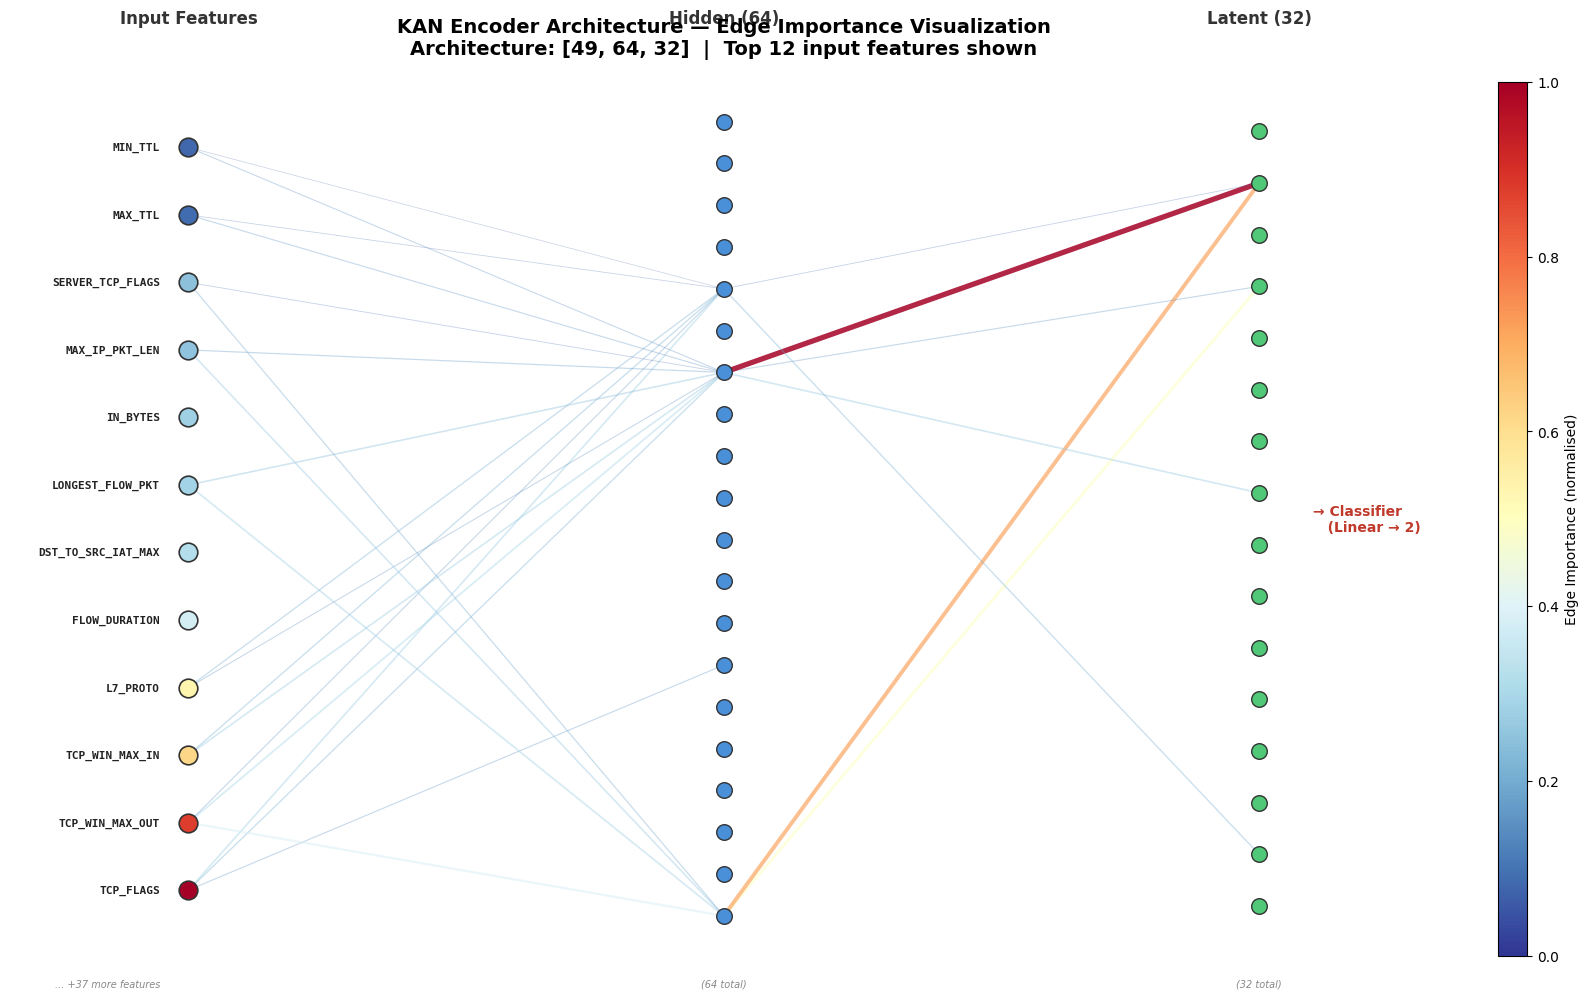

[Viz] B-spline activation plots saved to kan_bspline_activations.png


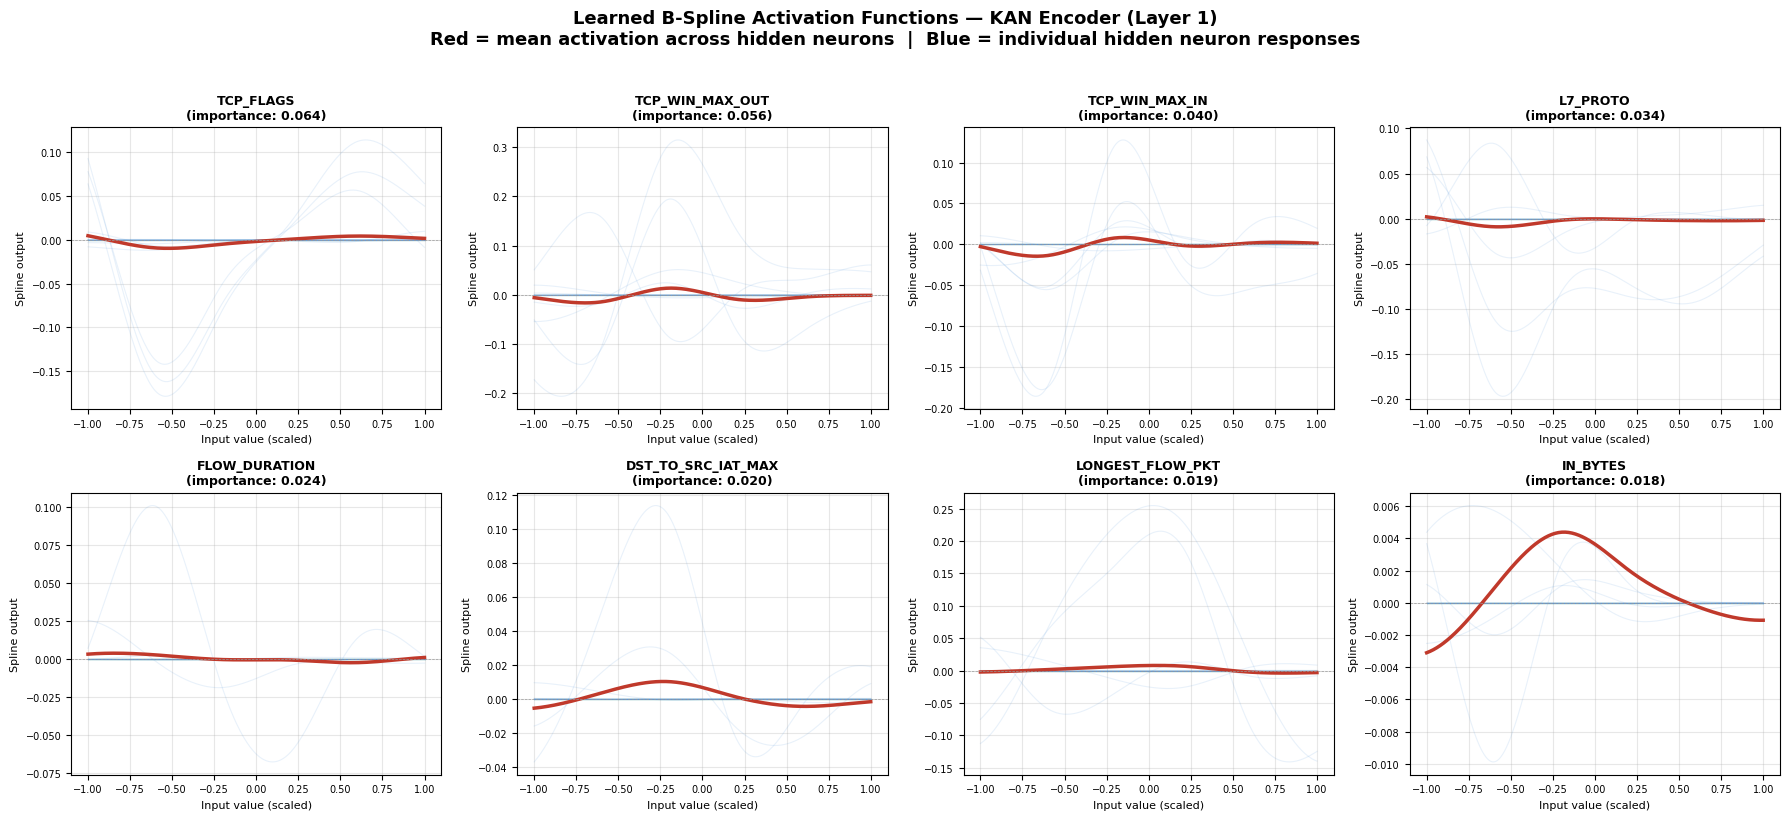

[Viz] Feature importance bar chart saved to kan_feature_importance.png


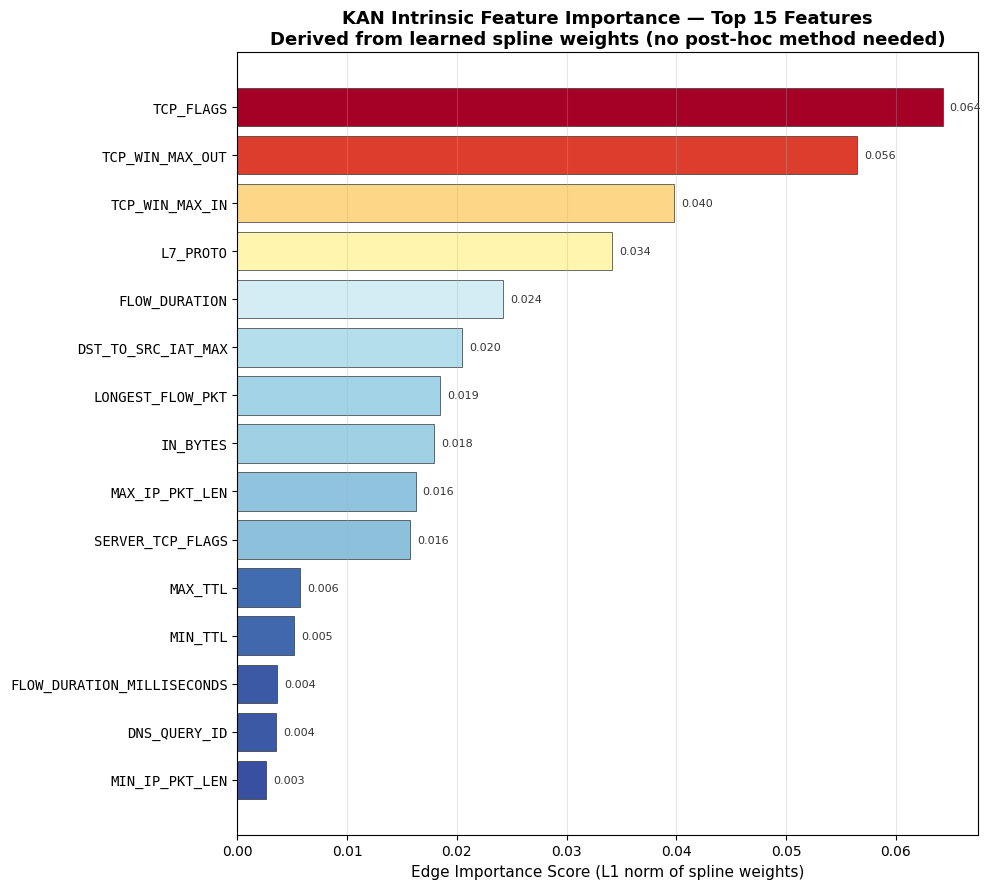


[Viz] All figures saved. Summary:
  1. kan_architecture.png      — Network structure + edge importance
  2. kan_bspline_activations.png — Learned spline transformations
  3. kan_feature_importance.png — Feature ranking bar chart


In [28]:
# ============================================================================
# KAN ARCHITECTURE VISUALIZATION FOR NIDS EXPLAINABILITY
# ============================================================================
# Append this code AFTER your model has been trained (after pretrain_source).
# It produces two publication-ready figures:
#   Figure 1: KAN encoder architecture diagram with edge-importance weighting
#   Figure 2: Top-K learned B-spline activation functions per input feature
#
# References:
#   - Barašin et al. (2024) "Exploring KANs for Interpretable Time Series
#     Classification" (arXiv:2411.14904) — edge scores & B-spline viz
#   - Liu et al. (2024) "KAN: Kolmogorov-Arnold Networks" (ICLR 2025)
#     — network "brain" visualization
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
import numpy as np
import torch
import torch.nn as nn
from scipy.interpolate import BSpline

# ── Ensure model is in eval mode and on CPU for weight extraction ─────────
model.eval()


# ============================================================================
# STEP 1: Extract feature names from your dataset pipeline
# ============================================================================
def get_feature_names(dataset_name='seyhed/nf-cicids2018-v3'):
    """
    Re-load a tiny slice of the source CSV just to grab column names
    after feature engineering. Avoids hard-coding feature names.
    """
    import kagglehub, os
    path = kagglehub.dataset_download(dataset_name)
    csv_files = [
        os.path.join(root, f)
        for root, _, files in os.walk(path)
        for f in files if f.endswith('.csv')
    ]
    df_sample = pl.scan_csv(csv_files[0]).head(5).collect()
    df_sample = engineer_features(df_sample)
    return df_sample.columns

try:
    feature_names = get_feature_names()
    print(f"[Viz] Extracted {len(feature_names)} feature names: {feature_names[:5]}...")
except Exception as e:
    print(f"[Viz] Could not extract feature names ({e}), using generic names.")
    feature_names = [f"f{i}" for i in range(input_dim)]


# ============================================================================
# STEP 2: Extract edge importance from EfficientKAN encoder
# ============================================================================
def extract_edge_importance(kan_module):
    """
    For each KANLinear layer in the EfficientKAN, compute edge importance
    as the L1 norm of spline_weight across the grid dimension.

    spline_weight shape: (out_features, in_features, grid_size + spline_order)
    edge_importance:     (out_features, in_features)  — one score per edge

    If spline_scaler exists, multiply it in (it scales each activation).
    """
    layer_importances = []
    layer_shapes = []

    for layer in kan_module.layers:
        sw = layer.spline_weight.detach().cpu()          # (out, in, G+k)
        importance = sw.abs().mean(dim=2)                 # (out, in)

        # Include spline_scaler if present (scales each edge's activation)
        if hasattr(layer, 'spline_scaler') and layer.spline_scaler is not None:
            scaler = layer.spline_scaler.detach().cpu()   # (out, in)
            importance = importance * scaler.abs()

        layer_importances.append(importance.numpy())
        layer_shapes.append((layer.in_features, layer.out_features))

    return layer_importances, layer_shapes


def compute_input_feature_importance(layer_importances):
    """
    Aggregate edge importance from input layer through the full encoder
    to get a single importance score per input feature.

    For a 2-layer encoder [input→64→latent]:
      Layer 0 importance: (64, input_dim)
      Layer 1 importance: (latent_dim, 64)

      Input feature importance = sum over all paths from input to latent:
        score[i] = sum_j ( L0[j, i] * sum_k L1[k, j] )

    This gives us a single importance score per input feature.
    """
    # Layer 0: (64, input_dim) — importance of each input feature to each hidden node
    L0 = layer_importances[0]   # (64, input_dim)

    if len(layer_importances) > 1:
        # Layer 1: (latent_dim, 64) — importance of each hidden node to each latent node
        L1 = layer_importances[1]   # (latent_dim, 64)
        # Aggregate: for each input feature, sum the product of paths
        # L1_agg[j] = sum over k of L1[k, j] — total outgoing importance of hidden node j
        L1_agg = L1.sum(axis=0)     # (64,)
        # Weighted sum: input_importance[i] = sum_j (L0[j,i] * L1_agg[j])
        input_importance = (L0 * L1_agg[:, None]).sum(axis=0)  # (input_dim,)
    else:
        input_importance = L0.sum(axis=0)

    return input_importance


# ── Run extraction ────────────────────────────────────────────────────────
if config.arch == 'kan':
    encoder = model.encoder
    layer_importances, layer_shapes = extract_edge_importance(encoder)
    input_importance = compute_input_feature_importance(layer_importances)

    # Normalise to [0, 1]
    input_importance_norm = input_importance / (input_importance.max() + 1e-8)

    # Rank features
    ranked_idx = np.argsort(input_importance)[::-1]
    print("\n[Viz] Top-10 most important input features (by edge score):")
    for rank, idx in enumerate(ranked_idx[:10]):
        name = feature_names[idx] if idx < len(feature_names) else f"f{idx}"
        print(f"  {rank+1:2d}. {name:30s}  importance={input_importance[idx]:.4f}")
else:
    print("[Viz] Architecture is not 'kan'. Skipping KAN-specific visualization.")
    print("      Set config.arch = 'kan' and retrain to use this visualization.")


# ============================================================================
# FIGURE 1: KAN Encoder Architecture Diagram
# ============================================================================
def plot_kan_architecture(layer_importances, layer_shapes, feature_names,
                          top_k=12, save_path='kan_architecture.png'):
    """
    Draw the KAN encoder as a node-edge graph (like Fig.8 in Barašin et al.).

    - Nodes are arranged in columns (one per layer)
    - Edge thickness ∝ importance (L1 norm of spline weights)
    - Edge colour = importance (blue→red colourmap)
    - Only top_k input features shown (rest collapsed into "... +N more")
    - Hidden and latent layers shown in full (64, 32 — manageable sizes)

    For large hidden layers, we cap displayed nodes and annotate.
    """
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    ax.set_xlim(-0.5, 3.5)

    # ── Determine which input features to show ────────────────────────────
    n_input = layer_shapes[0][0]
    input_imp = compute_input_feature_importance(layer_importances)
    top_indices = np.argsort(input_imp)[::-1][:top_k]
    n_hidden = layer_shapes[0][1]
    n_latent = layer_shapes[1][1] if len(layer_shapes) > 1 else layer_shapes[0][1]

    # Cap displayed nodes for hidden/latent layers
    max_display_hidden = min(n_hidden, 20)
    max_display_latent = min(n_latent, 16)

    # ── Node positions ────────────────────────────────────────────────────
    # Layer x-positions
    x_positions = [0.0, 1.5, 3.0]
    layer_labels = ['Input Features', f'Hidden ({n_hidden})', f'Latent ({n_latent})']

    # Y positions for each layer (centred)
    def make_y_positions(n_display, total):
        ys = np.linspace(0, 1, n_display + 2)[1:-1]  # exclude endpoints
        return ys

    y_input  = make_y_positions(top_k, n_input)
    y_hidden = make_y_positions(max_display_hidden, n_hidden)
    y_latent = make_y_positions(max_display_latent, n_latent)

    # ── Draw edges: Layer 0 (Input → Hidden) ──────────────────────────────
    L0 = layer_importances[0]  # (hidden, input)
    L0_norm = L0 / (L0.max() + 1e-8)

    cmap = plt.cm.RdYlBu_r  # Red = high importance, Blue = low

    # Only draw edges from top_k input features to displayed hidden nodes
    for i_disp, i_feat in enumerate(top_indices):
        for j in range(max_display_hidden):
            imp = L0_norm[j, i_feat]
            if imp < 0.05:  # skip near-zero edges for clarity
                continue
            lw = 0.3 + imp * 3.5  # linewidth 0.3 to 3.8
            color = cmap(imp)
            ax.plot(
                [x_positions[0], x_positions[1]],
                [y_input[i_disp], y_hidden[j]],
                color=color, alpha=0.25 + imp * 0.6, linewidth=lw,
                solid_capstyle='round', zorder=1
            )

    # ── Draw edges: Layer 1 (Hidden → Latent) ────────────────────────────
    if len(layer_importances) > 1:
        L1 = layer_importances[1]  # (latent, hidden)
        L1_norm = L1 / (L1.max() + 1e-8)

        for j in range(max_display_hidden):
            for k in range(max_display_latent):
                imp = L1_norm[k, j]
                if imp < 0.05:
                    continue
                lw = 0.3 + imp * 3.5
                color = cmap(imp)
                ax.plot(
                    [x_positions[1], x_positions[2]],
                    [y_hidden[j], y_latent[k]],
                    color=color, alpha=0.25 + imp * 0.6, linewidth=lw,
                    solid_capstyle='round', zorder=1
                )

    # ── Draw nodes ────────────────────────────────────────────────────────
    node_size = 180

    # Input nodes (coloured by importance)
    for i_disp, i_feat in enumerate(top_indices):
        imp = input_imp[i_feat] / (input_imp.max() + 1e-8)
        color = cmap(imp)
        ax.scatter(x_positions[0], y_input[i_disp], s=node_size,
                   c=[color], edgecolors='#333', linewidths=1.2, zorder=5)
        name = feature_names[i_feat] if i_feat < len(feature_names) else f"f{i_feat}"
        ax.text(x_positions[0] - 0.08, y_input[i_disp], name,
                ha='right', va='center', fontsize=8, fontweight='bold',
                fontfamily='monospace', color='#222')

    # Annotation for remaining features
    n_remaining = n_input - top_k
    if n_remaining > 0:
        ax.text(x_positions[0] - 0.08, -0.03, f"... +{n_remaining} more features",
                ha='right', va='center', fontsize=7, fontstyle='italic', color='#888')

    # Hidden nodes
    for j in range(max_display_hidden):
        ax.scatter(x_positions[1], y_hidden[j], s=node_size * 0.7,
                   c='#4a90d9', edgecolors='#333', linewidths=1.0, zorder=5)
    if n_hidden > max_display_hidden:
        ax.text(x_positions[1], -0.03, f"({n_hidden} total)",
                ha='center', va='center', fontsize=7, fontstyle='italic', color='#888')

    # Latent nodes
    for k in range(max_display_latent):
        ax.scatter(x_positions[2], y_latent[k], s=node_size * 0.7,
                   c='#50c878', edgecolors='#333', linewidths=1.0, zorder=5)
    if n_latent > max_display_latent:
        ax.text(x_positions[2], -0.03, f"({n_latent} total)",
                ha='center', va='center', fontsize=7, fontstyle='italic', color='#888')

    # ── Layer labels ──────────────────────────────────────────────────────
    for i, (x, label) in enumerate(zip(x_positions, layer_labels)):
        ax.text(x, 1.06, label, ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='#333')

    # ── Classifier head annotation ────────────────────────────────────────
    ax.annotate('→ Classifier\n   (Linear → 2)',
                xy=(x_positions[2] + 0.15, 0.5), fontsize=10,
                fontweight='bold', color='#c0392b',
                ha='left', va='center')

    # ── Colourbar ─────────────────────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.04, aspect=30)
    cbar.set_label('Edge Importance (normalised)', fontsize=10)

    # ── Title & cleanup ───────────────────────────────────────────────────
    ax.set_title(
        'KAN Encoder Architecture — Edge Importance Visualization\n'
        f'Architecture: [{n_input}, {n_hidden}, {n_latent}]  |  '
        f'Top {top_k} input features shown',
        fontsize=14, fontweight='bold', pad=20
    )
    ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"[Viz] Architecture diagram saved to {save_path}")
    plt.show()
    return fig


# ============================================================================
# FIGURE 2: Learned B-Spline Activation Functions (Top-K Features)
# ============================================================================
def compute_bspline_output(kan_layer, feature_idx, x_range=(-1, 1), n_points=200):
    """
    Evaluate the learned B-spline activation function for a specific
    input feature across a range of input values.

    For EfficientKAN's KANLinear:
      - grid: (in_features, grid_size + 2*spline_order + 1)
      - spline_weight: (out_features, in_features, grid_size + spline_order)
      - spline_order: int (default 3 = cubic)

    We compute the spline output for this feature aggregated across all
    output neurons (sum of absolute contributions) to show the feature's
    overall learned transformation.
    """
    grid = kan_layer.grid.detach().cpu().numpy()         # (in_features, n_knots)
    sw   = kan_layer.spline_weight.detach().cpu().numpy() # (out, in, G+k)
    k    = kan_layer.spline_order

    # Knot vector for this feature
    knots = grid[feature_idx]  # (grid_size + 2*spline_order + 1,)
    n_bases = sw.shape[2]      # grid_size + spline_order

    # Evaluate each B-spline basis at x_points
    x_points = np.linspace(x_range[0], x_range[1], n_points)

    # Build individual B-spline bases
    basis_values = np.zeros((n_points, n_bases))
    for b in range(n_bases):
        # Each basis function uses k+1+1 knots starting at position b
        local_knots = knots[b:b + k + 2]
        if len(local_knots) < k + 2:
            continue
        # Construct B-spline with coefficient = 1 for this basis
        coeffs = np.zeros(n_bases)
        coeffs[b] = 1.0
        try:
            spl = BSpline(knots, coeffs, k, extrapolate=False)
            vals = spl(x_points)
            vals = np.nan_to_num(vals, 0.0)
            basis_values[:, b] = vals
        except Exception:
            pass

    # Aggregate: weighted sum across output neurons
    # sw[:, feature_idx, :] has shape (out_features, n_bases)
    weights_for_feature = sw[:, feature_idx, :]  # (out, n_bases)

    # Average activation across all output neurons (shows overall transformation)
    avg_activation = np.mean(weights_for_feature, axis=0)  # (n_bases,)
    y_avg = basis_values @ avg_activation

    # Also compute per-output-neuron activations for a "spread" visualization
    y_all = basis_values @ weights_for_feature.T  # (n_points, out_features)

    return x_points, y_avg, y_all


def plot_bspline_activations(kan_module, feature_names, input_importance,
                             top_k=8, save_path='kan_bspline_activations.png'):
    """
    Plot learned B-spline activation functions for the top-K input features.

    Following Barašin et al., each subplot shows:
      - The aggregated spline curve (bold line) — the overall transformation
      - Individual per-output-neuron curves (thin, transparent) — spread
      - Feature name and importance score as title

    This reveals HOW the KAN transforms each feature — e.g., amplifying
    certain value ranges (suspicious traffic) while suppressing others.
    """
    ranked_idx = np.argsort(input_importance)[::-1][:top_k]
    first_layer = kan_module.layers[0]

    n_cols = 4
    n_rows = int(np.ceil(top_k / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = np.atleast_2d(axes)

    for plot_i, feat_idx in enumerate(ranked_idx):
        row, col = divmod(plot_i, n_cols)
        ax = axes[row, col]

        x_pts, y_avg, y_all = compute_bspline_output(first_layer, feat_idx)

        # Plot per-neuron curves (spread)
        for j in range(min(y_all.shape[1], 20)):  # cap at 20 for clarity
            ax.plot(x_pts, y_all[:, j], color='#4a90d9', alpha=0.12, linewidth=0.8)

        # Plot aggregated curve (bold)
        ax.plot(x_pts, y_avg, color='#c0392b', linewidth=2.5, label='Mean activation')

        # Zero line
        ax.axhline(y=0, color='#999', linewidth=0.5, linestyle='--')

        name = feature_names[feat_idx] if feat_idx < len(feature_names) else f"f{feat_idx}"
        imp_score = input_importance[feat_idx]
        ax.set_title(f'{name}\n(importance: {imp_score:.3f})', fontsize=9, fontweight='bold')
        ax.set_xlabel('Input value (scaled)', fontsize=8)
        ax.set_ylabel('Spline output', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(top_k, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row, col].set_visible(False)

    fig.suptitle(
        'Learned B-Spline Activation Functions — KAN Encoder (Layer 1)\n'
        'Red = mean activation across hidden neurons  |  '
        'Blue = individual hidden neuron responses',
        fontsize=13, fontweight='bold', y=1.02
    )
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"[Viz] B-spline activation plots saved to {save_path}")
    plt.show()
    return fig


# ============================================================================
# FIGURE 3 (BONUS): Feature Importance Bar Chart with Ranking
# ============================================================================
def plot_feature_importance_bar(input_importance, feature_names,
                                top_k=15, save_path='kan_feature_importance.png'):
    """
    Horizontal bar chart of top-K features ranked by KAN edge importance.
    This is the simplest and most intuitive explainability figure — directly
    comparable to SHAP summary plots but derived from KAN's intrinsic structure.
    """
    ranked_idx = np.argsort(input_importance)[::-1][:top_k]
    scores = input_importance[ranked_idx]
    names  = [feature_names[i] if i < len(feature_names) else f"f{i}" for i in ranked_idx]

    # Normalise for colour mapping
    scores_norm = scores / (scores.max() + 1e-8)

    fig, ax = plt.subplots(figsize=(10, 0.5 * top_k + 1.5))
    cmap = plt.cm.RdYlBu_r
    colors = [cmap(s) for s in scores_norm]

    bars = ax.barh(range(top_k), scores[::-1], color=colors[::-1],
                   edgecolor='#333', linewidth=0.5)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(names[::-1], fontsize=10, fontfamily='monospace')
    ax.set_xlabel('Edge Importance Score (L1 norm of spline weights)', fontsize=11)
    ax.set_title(
        f'KAN Intrinsic Feature Importance — Top {top_k} Features\n'
        'Derived from learned spline weights (no post-hoc method needed)',
        fontsize=13, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3)

    # Annotate values
    for i, (score, bar) in enumerate(zip(scores[::-1], bars)):
        ax.text(score + scores.max() * 0.01, i, f'{score:.3f}',
                va='center', fontsize=8, color='#333')

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"[Viz] Feature importance bar chart saved to {save_path}")
    plt.show()
    return fig


# ============================================================================
# RUN ALL VISUALIZATIONS
# ============================================================================
if config.arch == 'kan':
    print('\n' + '=' * 60)
    print('KAN EXPLAINABILITY VISUALIZATIONS')
    print('=' * 60)

    # Figure 1: Architecture diagram
    fig1 = plot_kan_architecture(
        layer_importances, layer_shapes, feature_names,
        top_k=min(12, input_dim),
        save_path='kan_architecture.png'
    )

    # Figure 2: B-spline activation functions
    fig2 = plot_bspline_activations(
        model.encoder, feature_names, input_importance,
        top_k=min(8, input_dim),
        save_path='kan_bspline_activations.png'
    )

    # Figure 3: Feature importance bar chart
    fig3 = plot_feature_importance_bar(
        input_importance, feature_names,
        top_k=min(15, input_dim),
        save_path='kan_feature_importance.png'
    )

    print('\n[Viz] All figures saved. Summary:')
    print('  1. kan_architecture.png      — Network structure + edge importance')
    print('  2. kan_bspline_activations.png — Learned spline transformations')
    print('  3. kan_feature_importance.png — Feature ranking bar chart')
else:
    print(f"\n[Viz] Current arch is '{config.arch}'. "
          "Set config.arch = 'kan' and retrain to generate KAN visualizations.")